In [1]:
import os
import sys
import gc
import torch
import numpy as np
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

!pip install captum
from captum.attr import IntegratedGradients

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.9 MB/s eta 0:00:00
Using device: cuda


In [2]:
import sys
import os
DATASET_DIR = '/kaggle/input/datasets/ppark8798/smartbug/'
MODEL_PATH = '/kaggle/input/models/ppark8798/baseline-model/pytorch/default/9'
CONTRASTIVE_PATH = '/kaggle/input/datasets/mailuongg/codebert-contrastive-2/actual_model'
EVAL_PATH = '/kaggle/input/datasets/ppark8798/evaluation'

def add_path(path):
    if path not in sys.path:
        sys.path.insert(0, path)
        print(f"[INFO] Added to path: {path}")

add_path(MODEL_PATH)
add_path(CONTRASTIVE_PATH)
add_path(EVAL_PATH)

import baseline
import eval_datasets
import evaluate
from evaluate import Evaluator

from codebert_contrastive import CodeBERTContrastiveEncoder
import interpret

[INFO] Added to path: /kaggle/input/models/ppark8798/baseline-model/pytorch/default/9
[INFO] Added to path: /kaggle/input/datasets/mailuongg/codebert-contrastive-2/actual_model
[INFO] Added to path: /kaggle/input/datasets/ppark8798/evaluation


In [3]:
eval_data = torch.load(
    os.path.join(DATASET_DIR, "test_chunks_eval.pt"),
    map_location="cpu"
)

print(f"Loaded {len(eval_data)} evaluation chunks.")

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
PAD_ID = tokenizer.pad_token_id
print(f"Tokenizer PAD token id: {PAD_ID}")

test_dataset = eval_datasets.SmartContractEvalDataset(
    eval_data,
    tokenizer=tokenizer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,   # safer than 256 for CodeBERT
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Loaded 33614 evaluation chunks.


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Tokenizer PAD token id: 1


In [4]:
PATH_BASELINE = "/kaggle/input/notebooks/ppark8798/train-baseline/best_model.pt"

baseline_model = baseline.BaselineModel()

baseline_ckpt = torch.load(
    PATH_BASELINE,
    map_location=device,
    weights_only=False
)

baseline_model.load_state_dict(
    baseline_ckpt["model_state_dict"]
)

baseline_model.to(device)
baseline_model.eval()

print("Baseline model loaded successfully.")

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Baseline model loaded successfully.


In [5]:
PATH_CONTRASTIVE = '/kaggle/input/notebooks/ppark8798/train-semanticbert/outputs/best-checkpoint/model.pt'
contrastive_model = CodeBERTContrastiveEncoder()

contrastive_ckpt = torch.load(
    PATH_CONTRASTIVE,
    map_location=device,
    weights_only=False
)

contrastive_model.load_state_dict(contrastive_ckpt)

contrastive_model.to(device)
contrastive_model.eval() 
print("Contrastive model loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Contrastive model loaded successfully.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc
)

def make_evaluation_figures(results, model_name="Model"):
    """
    Generate all key evaluation figures from Evaluator results.

    Args:
        results: dict from Evaluator.evaluate()
        model_name: string for titles
    """

    y_true = np.array(results["raw_labels"])
    y_probs = np.array(results["raw_probs"])
    threshold = results["threshold"]
    y_pred = (y_probs > threshold).astype(int)

    print(f"\n=== Generating Figures: {model_name} ===")

    # -----------------------------
    # 1. Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Safe", "Vulnerable"])
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # -----------------------------
    # 2. Precision-Recall Curve
    # -----------------------------
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # -----------------------------
    # 3. ROC Curve
    # -----------------------------
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # -----------------------------
    # 4. Probability Distribution
    # -----------------------------
    plt.figure(figsize=(7, 5))
    plt.hist(y_probs[y_true == 0], bins=50, alpha=0.5, label="Safe")
    plt.hist(y_probs[y_true == 1], bins=50, alpha=0.5, label="Vulnerable")
    plt.axvline(threshold, linestyle="--", label="Threshold")
    plt.title(f"{model_name} - Probability Distribution")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [7]:
def make_comparison_figures(results_a, results_b, name_a="Baseline", name_b="Contrastive"):
    y_true_a = np.array(results_a["raw_labels"])
    y_probs_a = np.array(results_a["raw_probs"])

    y_true_b = np.array(results_b["raw_labels"])
    y_probs_b = np.array(results_b["raw_probs"])

    # -----------------------------
    # PR Curve Comparison
    # -----------------------------
    p_a, r_a, _ = precision_recall_curve(y_true_a, y_probs_a)
    p_b, r_b, _ = precision_recall_curve(y_true_b, y_probs_b)

    auc_a = auc(r_a, p_a)
    auc_b = auc(r_b, p_b)

    plt.figure(figsize=(8, 6))
    plt.plot(r_a, p_a, linestyle="--", label=f"{name_a} (AUC={auc_a:.3f})")
    plt.plot(r_b, p_b, linewidth=2, label=f"{name_b} (AUC={auc_b:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # -----------------------------
    # ROC Comparison
    # -----------------------------
    from sklearn.metrics import roc_curve

    fpr_a, tpr_a, _ = roc_curve(y_true_a, y_probs_a)
    fpr_b, tpr_b, _ = roc_curve(y_true_b, y_probs_b)

    auc_a = auc(fpr_a, tpr_a)
    auc_b = auc(fpr_b, tpr_b)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_a, tpr_a, linestyle="--", label=f"{name_a} (AUC={auc_a:.3f})")
    plt.plot(fpr_b, tpr_b, linewidth=2, label=f"{name_b} (AUC={auc_b:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

interpretability:

In [8]:
def run_invariance_comparison(baseline_eval, contrast_eval, eval_data, save_dir):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    print("\n[Invariance] Running baseline vs contrastive...")

    baseline_dist = baseline_eval.evaluate_invariance(eval_data)
    contrast_dist = contrast_eval.evaluate_invariance(eval_data)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(8,5))

    plt.hist(contrast_dist, bins=50, alpha=0.6, label="Contrastive")

    if baseline_dist is not None:
        plt.hist(baseline_dist, bins=50, alpha=0.6, label="Baseline")

    plt.legend()
    plt.title("Embedding Invariance Comparison")
    plt.xlabel("Cosine Distance (lower = better)")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, "invariance_compare.png"))
    plt.show()

    print(f"Contrastive mean: {np.mean(contrast_dist):.4f}")
    if baseline_dist is not None:
        print(f"Baseline mean: {np.mean(baseline_dist):.4f}")

    return baseline_dist, contrast_dist

In [9]:
def run_interpretability_comparison(
    baseline_eval,
    contrast_eval,
    eval_data,
    device,
    tokenizer,
    save_dir,
    n_samples=50
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    print("\n[Interpretability] Running baseline vs contrastive...")
    baseline_eval.model.cpu()
    contrast_eval.model.cpu()

    gc.collect()
    torch.cuda.empty_cache()

    cpu_device = torch.device("cpu")

    baseline_jaccard, baseline_spearman = make_interpretability_figures(
        model=baseline_eval.model,
        eval_data=eval_data,
        device=cpu_device,
        tokenizer=tokenizer,
        n_samples=n_samples,
        is_contrastive=False
    )
    contrast_jaccard, contrast_spearman = make_interpretability_figures(
        model=contrast_eval.model,
        eval_data=eval_data,
        device=cpu_device,
        tokenizer=tokenizer,
        n_samples=n_samples,
        is_contrastive=True
    )

    os.makedirs(save_dir, exist_ok=True)

    # -----------------------------
    # Plot 1: Jaccard
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(["Baseline", "Contrastive"],
                [np.mean(baseline_jaccard), np.mean(contrast_jaccard)],
                color=["steelblue", "darkorange"])
    axes[0].set_title("Attribution Consistency (Jaccard)")
    axes[0].set_ylabel("Mean Jaccard Score")
    axes[0].set_ylim(0, 1)

    axes[1].bar(["Baseline", "Contrastive"],
                [np.mean(baseline_spearman), np.mean(contrast_spearman)],
                color=["steelblue", "darkorange"])
    axes[1].set_title("Attribution Consistency (Spearman)")
    axes[1].set_ylabel("Mean Spearman Correlation")
    axes[1].set_ylim(-1, 1)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "interpretability_compare.png"))
    plt.show()

    print(f"Baseline  — Jaccard: {np.mean(baseline_jaccard):.4f} | Spearman: {np.mean(baseline_spearman):.4f}")
    print(f"Contrastive — Jaccard: {np.mean(contrast_jaccard):.4f} | Spearman: {np.mean(contrast_spearman):.4f}")

    # Restore models
    baseline_eval.model.to(device)
    contrast_eval.model.to(device)

    return baseline_jaccard, contrast_jaccard, baseline_spearman, contrast_spearman

In [10]:
from scipy.stats import spearmanr

def get_token_attr(current_model, input_ids, attention_mask, is_contrastive=False, n_steps=50):
    device = next(current_model.parameters()).device
    word_emb = current_model.encoder.embeddings.word_embeddings

    input_ids = input_ids.to(device).view(1, -1)
    attention_mask = attention_mask.to(device).view(1, -1).long()

    def forward_wrapper(embeds):
        batch_size = embeds.shape[0]
        expanded_mask = attention_mask.expand(batch_size, -1)

        outputs = current_model.encoder(
            inputs_embeds=embeds,
            attention_mask=expanded_mask
        )

        pooled = current_model.pooler(
            outputs.last_hidden_state,
            expanded_mask
        )

        if is_contrastive:
            projected = current_model.projection_head(pooled)
            logits = current_model.classifier_head(projected)
        else:
            logits = current_model.classifier(pooled).squeeze(-1)

        return torch.sigmoid(logits)

    ig = IntegratedGradients(forward_wrapper)

    input_embeds = word_emb(input_ids)
    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
    baseline_embeds = word_emb(baseline_ids)

    attr, _ = ig.attribute(
        input_embeds,
        baselines=baseline_embeds,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    return attr.squeeze(0).norm(dim=-1).detach().cpu().numpy()


def make_interpretability_figures(
    model,
    eval_data,
    device,
    tokenizer=None,
    max_length=256,
    n_samples=50,
    top_k=20,
    n_steps=50,
    save_path=None,
    is_contrastive=False
):
    model.eval()
    jaccard_scores = []
    spearman_scores = []

    for i in range(min(n_samples, len(eval_data))):
        item = eval_data[i]

        a_ids = torch.tensor(item["anchor_input_ids"][:max_length]).to(device)
        p_ids = torch.tensor(item["pos_input_ids"][:max_length]).to(device)
        pad_id = tokenizer.pad_token_id
        a_mask = a_ids.ne(pad_id).long()
        p_mask = p_ids.ne(pad_id).long()

        a_attr = get_token_attr(model, a_ids, a_mask, is_contrastive=is_contrastive, n_steps=n_steps)
        p_attr = get_token_attr(model, p_ids, p_mask, is_contrastive=is_contrastive, n_steps=n_steps)

        # Spearman rank correlation
        min_len = min(len(a_attr), len(p_attr))
        corr, _ = spearmanr(a_attr[:min_len], p_attr[:min_len])
        spearman_scores.append(corr if not np.isnan(corr) else 0.0)

        # Jaccard top-k overlap
        top_a = set(np.argsort(a_attr)[::-1][:top_k])
        top_p = set(np.argsort(p_attr)[::-1][:top_k])
        inter = len(top_a & top_p)
        union = len(top_a | top_p)
        jaccard_scores.append(inter / union if union > 0 else 0)

        del a_attr, p_attr, a_ids, p_ids, a_mask, p_mask

    return np.array(jaccard_scores), np.array(spearman_scores)

In [11]:
def generate_full_report(
    baseline_eval,
    contrast_eval,
    test_loader,
    eval_data,
    device,
    tokenizer,
    save_dir="report_outputs"
):
    import os
    import gc
    import numpy as np
    import torch

    os.makedirs(save_dir, exist_ok=True)

    # helpful for long evaluation runs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\n==============================")
    print(" RUNNING FULL EXPERIMENT ")
    print("==============================")

    # =====================================================
    # 1. Standard Performance Evaluation
    # =====================================================
    print("\n[1] Performance Evaluation")

    baseline_results = baseline_eval.evaluate(test_loader)
    contrast_results = contrast_eval.evaluate(test_loader)

    # =====================================================
    # 2. Visualization Figures
    # =====================================================
    print("\n[2] Generating Figures")

    make_evaluation_figures(
        baseline_results,
        model_name="Baseline"
    )

    make_evaluation_figures(
        contrast_results,
        model_name="Contrastive"
    )

    make_comparison_figures(
        baseline_results,
        contrast_results,
        name_a="Baseline",
        name_b="Contrastive"
    )

    # =====================================================
    # 3. Contract-Level Aggregation
    # =====================================================
    print("\n[3] Contract-Level Aggregation")

    contract_ids = [x["contract_id"] for x in eval_data]

    baseline_eval.aggregate_contracts(contract_ids)
    contrast_eval.aggregate_contracts(contract_ids)

    # =====================================================
    # 4. Failure Analysis
    # =====================================================
    print("\n[4] Failure Analysis")

    baseline_eval.failure_analysis(eval_data)
    contrast_eval.failure_analysis(eval_data)

    # =====================================================
    # 5. Robustness / Invariance (RQ1)
    # =====================================================
    print("\n[5] Robustness Evaluation (RQ1)")

    baseline_dist, contrast_dist = run_invariance_comparison(
        baseline_eval=baseline_eval,
        contrast_eval=contrast_eval,
        eval_data=eval_data,
        save_dir=save_dir
    )
    print("Anchor vs Positive:", np.mean(contrast_dist))

    # =====================================================
    # 6. Interpretability Consistency (RQ2)
    # =====================================================
    print("\n[6] Interpretability Evaluation (RQ2)")

    baseline_j, contrast_j, baseline_s, contrast_s = run_interpretability_comparison(
        baseline_eval=baseline_eval,
        contrast_eval=contrast_eval,
        eval_data=eval_data,
        device=device,
        tokenizer=tokenizer,
        save_dir=save_dir
    )

    # =====================================================
    # 7. Final Summary
    # =====================================================
    print("\n==============================")
    print(" FINAL RESULTS ")
    print("==============================")

    print(f"\nBaseline F1: {baseline_results['f1']:.4f}")
    print(f"Contrastive F1: {contrast_results['f1']:.4f}")

    print("\nRQ1 — Semantic Robustness (lower cosine distance = better)")
    print(f"Baseline distance: {np.mean(baseline_dist):.4f}")
    print(f"Contrastive distance: {np.mean(contrast_dist):.4f}")

    print("\nRQ2 — Attribution Consistency")
    print(f"Baseline Jaccard: {np.mean(baseline_j):.4f}")
    print(f"Contrastive Jaccard: {np.mean(contrast_j):.4f}")
    
    print(f"Baseline Spearman: {np.mean(baseline_s):.4f}")
    print(f"Contrastive Spearman: {np.mean(contrast_s):.4f}")

    print(f"\nSaved outputs to: {save_dir}")

In [12]:
# Create the evaluator objects
baseline_eval = Evaluator(
    baseline_model,
    device,
    model_name="Baseline",
    tokenizer=tokenizer
)
contrast_eval = Evaluator(
    contrastive_model, device, 
    is_contrastive=True, 
    model_name="Contrastive", 
    tokenizer=tokenizer
)

In [13]:
import types
import torch
import torch.nn.functional as F

# -----------------------------
# Baseline encoding (768-d pooled)
# -----------------------------
def baseline_encode(self, input_ids, attention_mask):
    self.eval()
    device = next(self.parameters()).device

    with torch.no_grad():
        outputs = self.encoder(
            input_ids=input_ids.to(device),
            attention_mask=attention_mask.to(device)
        )

        pooled = self.pooler(
            outputs.last_hidden_state,
            attention_mask.to(device)
        )

        pooled = F.normalize(pooled, p=2, dim=-1)

    return pooled


# -----------------------------
# Contrastive encoding (128-d projection space)
# THIS is the correct space for BOTH:
# - classification
# - invariance evaluation
# -----------------------------
def contrastive_encode(self, input_ids, attention_mask):
    self.eval()
    device = next(self.parameters()).device

    with torch.no_grad():
        outputs = self.encoder(
            input_ids=input_ids.to(device),
            attention_mask=attention_mask.to(device)
        )

        pooled = self.pooler(
            outputs.last_hidden_state,
            attention_mask.to(device)
        )

        # project to contrastive space
        emb = self.projection_head(pooled)
        emb = F.normalize(emb, p=2, dim=-1)

    return emb


# -----------------------------
# Inject into models
# -----------------------------

# Baseline model uses standard pooled embeddings
baseline_eval.model.encode_chunks = types.MethodType(
    baseline_encode,
    baseline_eval.model
)

# Contrastive model ALSO uses projection space consistently
contrast_eval.model.encode_chunks = types.MethodType(
    contrastive_encode,
    contrast_eval.model
)

print("✅ Encoding functions correctly injected (baseline + contrastive aligned).")

✅ Encoding functions correctly injected (baseline + contrastive aligned).


In [14]:
import types

# Define a patched forward that forces tensors to the model's device
def patched_forward(self, input_ids, attention_mask, contract_ids=None):
    device = next(self.parameters()).device
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    if contract_ids is not None:
        contract_ids = contract_ids.to(device)
        
    # Re-implement the original forward logic but with device-safe tensors
    outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
    pooled = self.pooler(outputs.last_hidden_state, attention_mask)
    chunk_logits = self.classifier(pooled).squeeze(-1)

    if contract_ids is not None:
        unique_ids = torch.unique(contract_ids)
        return torch.stack([torch.max(chunk_logits[contract_ids == cid]) for cid in unique_ids])
    
    return chunk_logits

# Apply the patch to the baseline model instance
baseline_eval.model.forward = types.MethodType(patched_forward, baseline_eval.model)

print("✅ Baseline forward pass patched for device safety. Try running the report now!")

✅ Baseline forward pass patched for device safety. Try running the report now!



 RUNNING FULL EXPERIMENT 

[1] Performance Evaluation

--- Evaluating: Baseline ---

--- Evaluating: Contrastive ---

[2] Generating Figures

=== Generating Figures: Baseline ===


<Figure size 500x500 with 0 Axes>

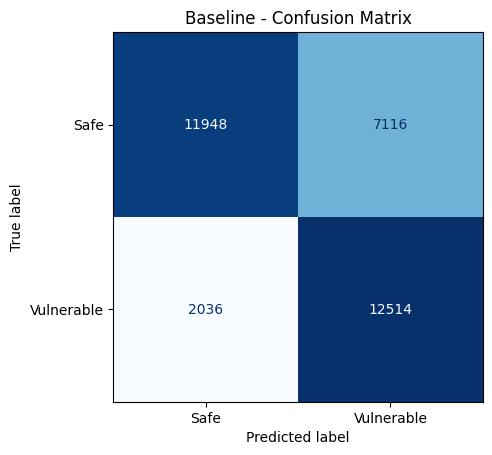

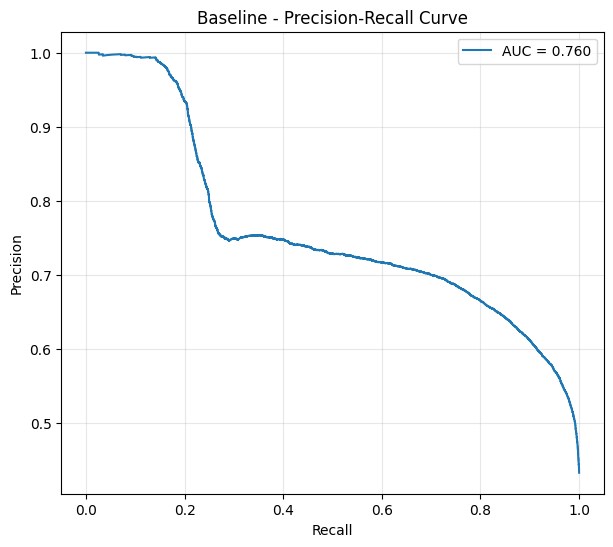

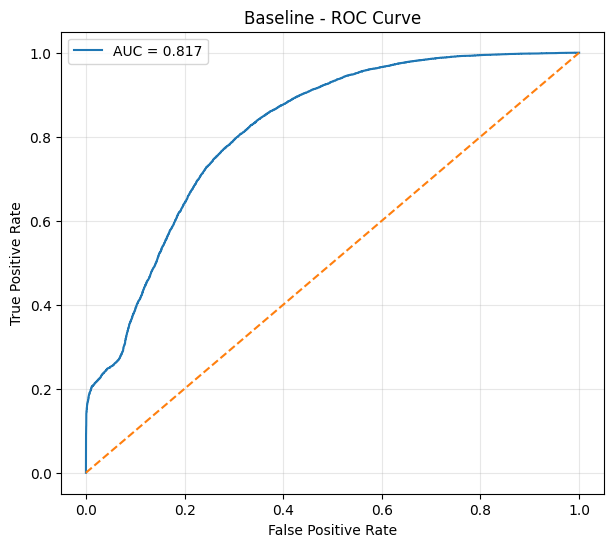

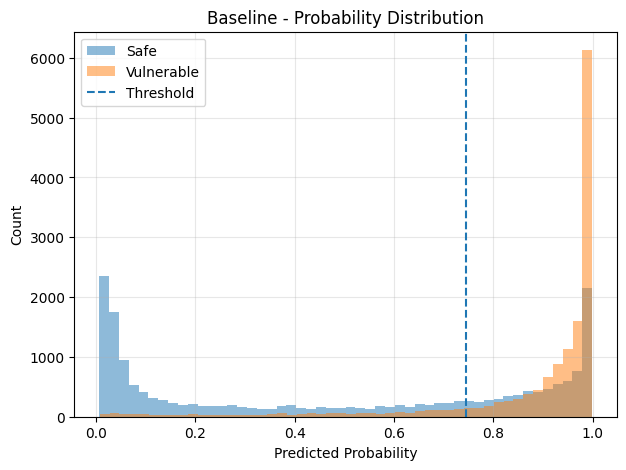


=== Generating Figures: Contrastive ===


<Figure size 500x500 with 0 Axes>

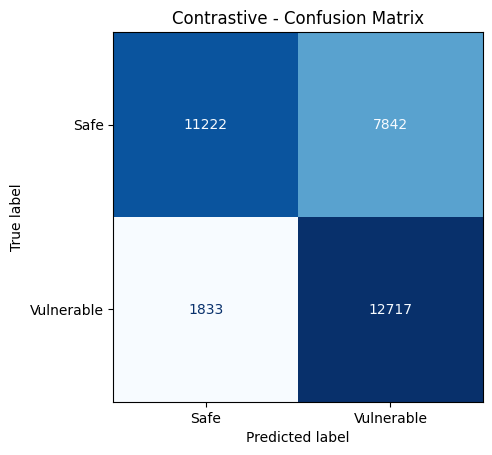

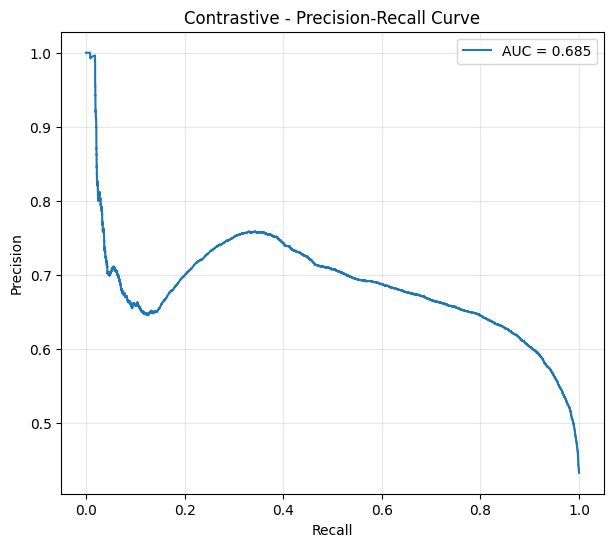

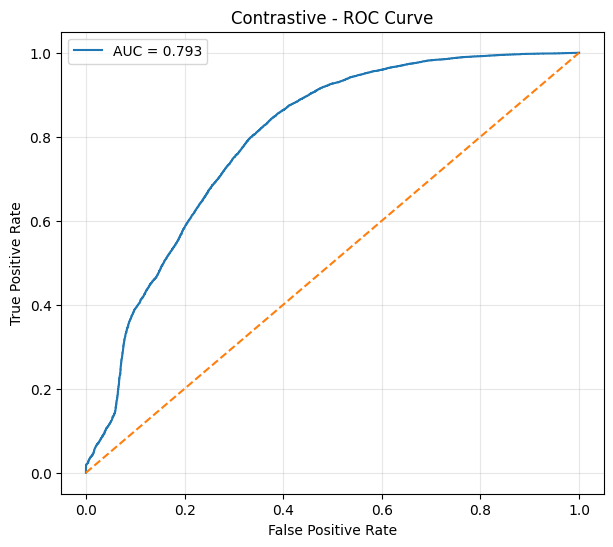

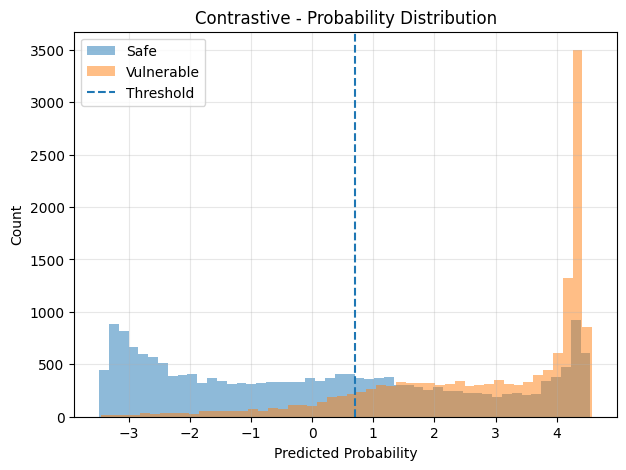

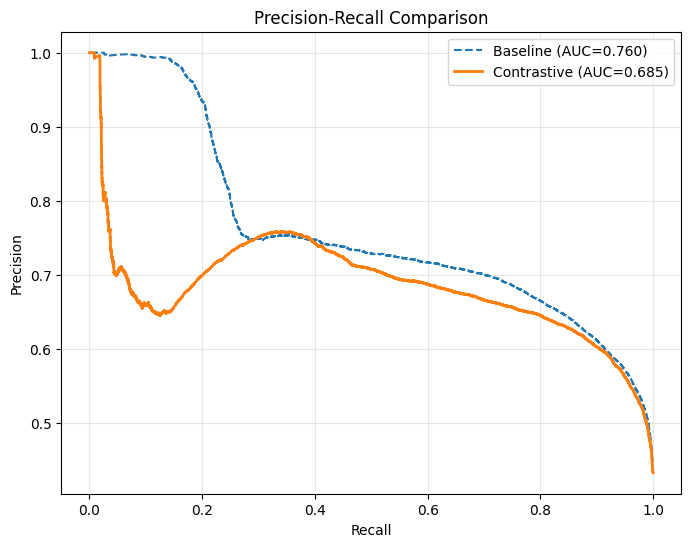

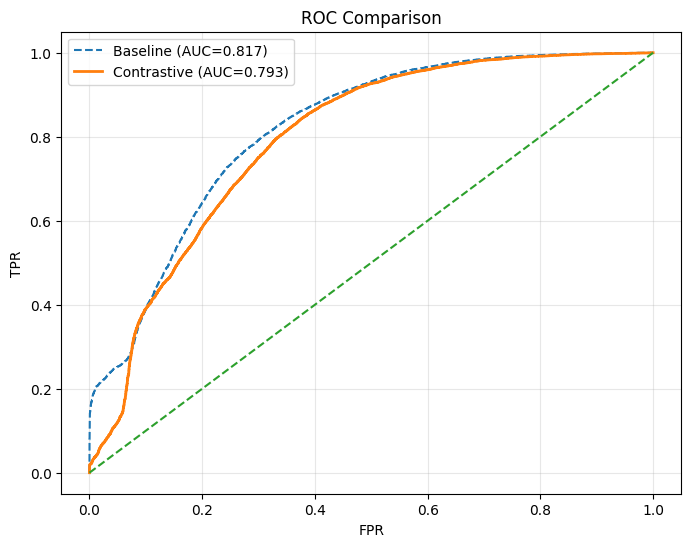


[3] Contract-Level Aggregation

[Baseline] Contract-Level (Strategy: max)
F1: 0.7701 | Acc: 0.6720

[Contrastive] Contract-Level (Strategy: max)
F1: 0.7701 | Acc: 0.6686

[4] Failure Analysis

=== Failure Analysis: Baseline ===

False Positive (FP):
Confidence Score: 0.8410

	}
	modifier onlyPayer() {
		require(msg.sender == payer);
		_;
	}
	modifier onlyRecipient() {
		require(msg.sender == recipient);
		_;
	}
	modifier onlyPayerOrRecipient() {
		require((msg.sender == payer) || (msg.sender == recipient));
		_;
	}

	event Created(address indexed contractAddress, addre
----------------------------------------
Confidence Score: 0.8890
 a, uint256 b) internal pure returns (uint256) {
        uint256 c = a + b;
        assert(c >= a);
        return c;
    }
}

contract Ownable {
    address public owner;

    event OwnershipTransferred(address indexed previousOwner, address indexed newOwner);

    constructor() public {
        ow
----------------------------------------
Confidence Scor

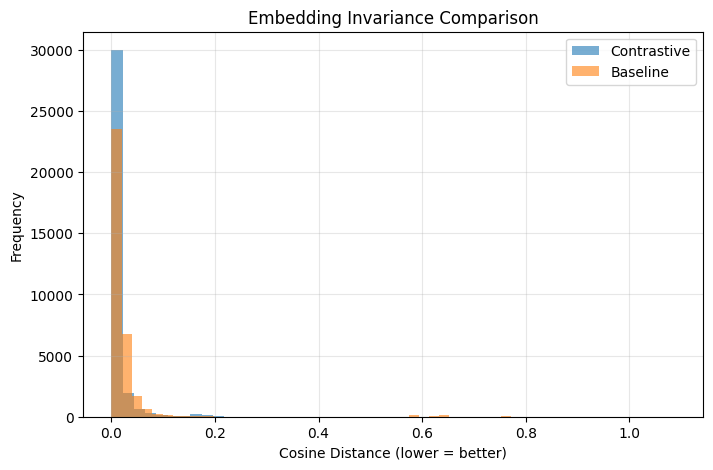

Contrastive mean: 0.0114
Baseline mean: 0.0257
Anchor vs Positive: 0.011350328

[6] Interpretability Evaluation (RQ2)

[Interpretability] Running baseline vs contrastive...


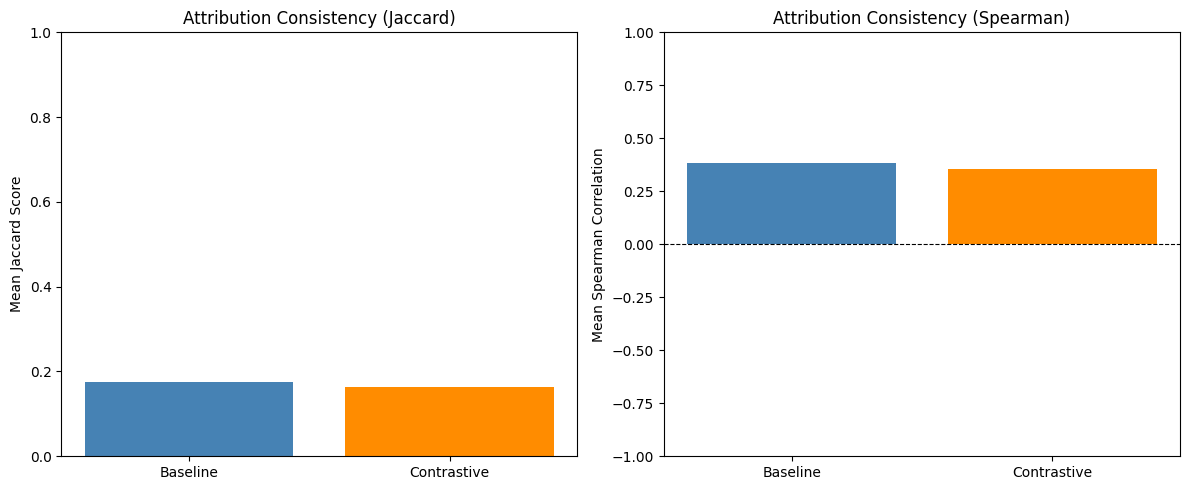

Baseline  — Jaccard: 0.1751 | Spearman: 0.3857
Contrastive — Jaccard: 0.1639 | Spearman: 0.3569

 FINAL RESULTS 

Baseline F1: 0.7322
Contrastive F1: 0.7244

RQ1 — Semantic Robustness (lower cosine distance = better)
Baseline distance: 0.0257
Contrastive distance: 0.0114

RQ2 — Attribution Consistency
Baseline Jaccard: 0.1751
Contrastive Jaccard: 0.1639
Baseline Spearman: 0.3857
Contrastive Spearman: 0.3569

Saved outputs to: report_outputs


In [15]:
generate_full_report(
    baseline_eval=baseline_eval,
    contrast_eval=contrast_eval,
    test_loader=test_loader,
    eval_data=eval_data,
    device=device,
    tokenizer=tokenizer,
    save_dir="report_outputs"
)